In [7]:
!pip install python-chess
!pip install torch torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-$(torch.__version__).html

/bin/bash: line 1: torch.__version__: command not found
Looking in links: https://data.pyg.org/whl/torch-.html
  Using cached torch_scatter-2.1.2.tar.gz (108 kB)
  Preparing metadata (setup.py) ... done
  Using cached torch_sparse-0.6.18.tar.gz (209 kB)
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Using cached torch_geometric-2.6.1-py3-none-any.whl.metadata (63 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 

In [10]:
!pip install torch_geometric
import chess
import torch
import torch.nn as nn # Used by GNN model later, good to have imports grouped
import torch.nn.functional as F # Used by GNN model later
import torch_geometric # For PyG specific functionalities
from torch_geometric.data import Data, Batch # Core PyG data structures
from torch_geometric.nn import GCNConv, global_mean_pool, GATConv # GNN layers
import numpy as np
import random
import gc # For garbage collection, if needed later

# ---------------------------------------------------------------------------
# CRITICAL CONSTANTS - Ensure this cell is run for these to be defined globally
# ---------------------------------------------------------------------------

# For consistent mapping from chess.Piece object to an integer index
# This dictionary requires 'chess' module to be imported first.
PIECE_TO_INDEX = {
    chess.PAWN: 0,
    chess.KNIGHT: 1,
    chess.BISHOP: 2,
    chess.ROOK: 3,
    chess.QUEEN: 4,
    chess.KING: 5
}

# Defines the number of features for each node (square) in our graph.
# Based on: 6 piece types * 2 colors (White/Black) + 1 for an 'empty' square.
# (6 White pieces + 6 Black pieces + 1 Empty = 13 features)
NUM_NODE_FEATURES = 13
# Note: We'll use one-hot encoding for these features in `piece_to_feature_vector`.
# For now, node features will *only* represent the piece on the square.
# Advanced features (castling rights, en passant square) could be added here
# or as global graph features.

# ---------------------------------------------------------------------------
# Device Configuration
# ---------------------------------------------------------------------------
# Set the computation device (GPU if available, otherwise CPU)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

  Using cached torch_geometric-2.6.1-py3-none-any.whl.metadata (63 kB)
Using cached torch_geometric-2.6.1-py3-none-any.whl (1.1 MB)
Using device: cuda


In [12]:
# (Ensure Cell 1: Imports and Chess Constants has been run successfully before this cell)
# This cell requires:
# - `chess` module
# - `torch` module
# - `PIECE_TO_INDEX` (dict for mapping piece types to integers)
# - `NUM_NODE_FEATURES` (int, total number of features for a square/node)
# - `DEVICE` (torch.device, e.g., 'cuda' or 'cpu')
# - `Data` from `torch_geometric.data`

def piece_to_feature_vector(piece):
    """
    Converts a chess.Piece object to a one-hot encoded feature vector.
    The vector indicates the piece type and color, or if the square is empty.

    Args:
        piece (chess.Piece or None): The piece on the square, or None if empty.

    Returns:
        torch.Tensor: A 1D tensor of shape [NUM_NODE_FEATURES].
    """
    # NUM_NODE_FEATURES should be 13:
    # 0-5: White Pawn, Knight, Bishop, Rook, Queen, King
    # 6-11: Black Pawn, Knight, Bishop, Rook, Queen, King
    # 12: Empty square
    vector = torch.zeros(NUM_NODE_FEATURES, dtype=torch.float) # Feature vector initialized to zeros

    if piece is None:
        vector[12] = 1.0  # Set the 'empty' feature
    else:
        piece_idx = PIECE_TO_INDEX[piece.piece_type] # Get base index for the piece type (0-5)
        color_offset = 0 if piece.color == chess.WHITE else 6 # Add 6 if piece is Black
        vector[piece_idx + color_offset] = 1.0 # Set the specific piece-color feature
    return vector # No .to(DEVICE) here, will be handled when stacking `x` in `board_to_graph_data`

def board_to_graph_data(board):
    """
    Converts a python-chess board object to a PyTorch Geometric Data object.
    Each square on the board becomes a node in the graph.

    Args:
        board (chess.Board): The current chess board state.

    Returns:
        torch_geometric.data.Data: A graph data object with node features (x)
                                   and edge connectivity (edge_index), moved to DEVICE.
    """
    node_features_list = []  # List to hold feature vectors for each square

    # Iterate through all 64 squares (A1 to H8, or 0 to 63)
    for square_index in chess.SQUARES: # chess.SQUARES is range(64)
        piece = board.piece_at(square_index) # Get piece at the current square
        node_features_list.append(piece_to_feature_vector(piece)) # Append its feature vector

    # Stack all node feature vectors into a single tensor
    # Shape: [64, NUM_NODE_FEATURES]
    x = torch.stack(node_features_list).to(DEVICE) # Move final node features tensor to DEVICE

    # Define graph connectivity (edges)
    # Here, we use a simple adjacency: each square connected to its immediate neighbors (like a king's move)
    # More complex edge definitions (e.g., based on piece attacks) are possible.
    edge_list = []
    for i in range(64): # For each square 'i'
        # Horizontal/Vertical adjacencies (Rook-like)
        if (i % 8) > 0: edge_list.append((i, i - 1))  # Connect to square to the left
        if (i % 8) < 7: edge_list.append((i, i + 1))  # Connect to square to the right
        if (i // 8) > 0: edge_list.append((i, i - 8)) # Connect to square below
        if (i // 8) < 7: edge_list.append((i, i + 8)) # Connect to square above

        # Diagonal adjacencies (Bishop-like)
        if (i % 8) > 0 and (i // 8) > 0: edge_list.append((i, i - 9))   # Top-left
        if (i % 8) < 7 and (i // 8) > 0: edge_list.append((i, i - 7))   # Top-right
        if (i % 8) > 0 and (i // 8) < 7: edge_list.append((i, i + 7))   # Bottom-left
        if (i % 8) < 7 and (i // 8) < 7: edge_list.append((i, i + 9))   # Bottom-right

        # Optional: Add Knight moves to the edge list
        # file_i, rank_i = i % 8, i // 8
        # for dr, df in [(2,1), (2,-1), (-2,1), (-2,-1), (1,2), (1,-2), (-1,2), (-1,-2)]:
        #     rank_j, file_j = rank_i + dr, file_i + df
        #     if 0 <= rank_j < 8 and 0 <= file_j < 8:
        #         j = rank_j * 8 + file_j
        #         edge_list.append((i,j))

    # Convert edge list to PyTorch Geometric's required format: [2, num_edges]
    # Also, ensure it's on the correct device.
    if not edge_list: # Should not happen with the above logic for a 64-square board
        edge_index = torch.empty((2, 0), dtype=torch.long).to(DEVICE)
    else:
        edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous().to(DEVICE)

    # Create the Data object
    # `x` and `edge_index` are already on `DEVICE`.
    data = Data(x=x, edge_index=edge_index)

    # Optional: Add global graph-level features (e.g., player to move, castling rights)
    # u_features = []
    # u_features.append(1.0 if board.turn == chess.WHITE else -1.0) # Player to move
    # u_features.append(1.0 if board.has_kingside_castling_rights(chess.WHITE) else 0.0)
    # u_features.append(1.0 if board.has_queenside_castling_rights(chess.WHITE) else 0.0)
    # u_features.append(1.0 if board.has_kingside_castling_rights(chess.BLACK) else 0.0)
    # u_features.append(1.0 if board.has_queenside_castling_rights(chess.BLACK) else 0.0)
    # if board.ep_square is not None:
    #     u_features.append(float(board.ep_square)) # Can be one-hot encoded too
    # else:
    #     u_features.append(-1.0) # Placeholder for no en-passant square
    # data.u = torch.tensor([u_features], dtype=torch.float).to(DEVICE)

    return data

# --- Example Usage and Test of this Cell's Functions ---
if __name__ == '__main__': # This block runs if the script is executed directly (won't run when just importing cells in Colab)
                          # For Colab, you'd put this test in a separate part of the cell or a new cell.

    # Ensure constants from Cell 1 are defined if running this standalone for testing
    # In Colab, these would already be in the global namespace if Cell 1 was run
    if 'PIECE_TO_INDEX' not in globals(): # Simple check
        print("WARNING: PIECE_TO_INDEX and other constants might not be defined. Define them as in Cell 1 for standalone testing.")
        PIECE_TO_INDEX = { chess.PAWN: 0, chess.KNIGHT: 1, chess.BISHOP: 2, chess.ROOK: 3, chess.QUEEN: 4, chess.KING: 5 }
        NUM_NODE_FEATURES = 13
        DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using (test) device: {DEVICE}")

    print("\n--- Testing Board Representation Utilities ---")
    board = chess.Board()
    print("Initial Board State:\n", board)

    # Test piece_to_feature_vector
    pawn_feature_vec = piece_to_feature_vector(board.piece_at(chess.A2)) # White Pawn on A2
    print("\nFeature vector for White Pawn (e.g., on A2):", pawn_feature_vec)
    print("Sum of features (should be 1.0):", pawn_feature_vec.sum().item())

    empty_feature_vec = piece_to_feature_vector(board.piece_at(chess.A3)) # Empty on A3
    print("Feature vector for Empty Square (e.g., on A3):", empty_feature_vec)
    print("Sum of features (should be 1.0):", empty_feature_vec.sum().item())

    # Test board_to_graph_data
    graph_data_example = board_to_graph_data(board)
    print("\nGenerated Graph Data Object:")
    print(graph_data_example)
    print(f"Node features (x) shape: {graph_data_example.x.shape}") # Expected: [64, NUM_NODE_FEATURES]
    print(f"Node features (x) device: {graph_data_example.x.device}")
    print(f"Edge index (edge_index) shape: {graph_data_example.edge_index.shape}") # Expected: [2, num_edges]
    print(f"Edge index (edge_index) device: {graph_data_example.edge_index.device}")
    # if hasattr(graph_data_example, 'u'):
    #     print(f"Global features (u) shape: {graph_data_example.u.shape}")
    #     print(f"Global features (u) device: {graph_data_example.u.device}")

    print(f"\nLegal moves (first 5): {list(board.legal_moves)[:5]}")


--- Testing Board Representation Utilities ---
Initial Board State:
 r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N R

Feature vector for White Pawn (e.g., on A2): tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
Sum of features (should be 1.0): 1.0
Feature vector for Empty Square (e.g., on A3): tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])
Sum of features (should be 1.0): 1.0

Generated Graph Data Object:
Data(x=[64, 13], edge_index=[2, 420])
Node features (x) shape: torch.Size([64, 13])
Node features (x) device: cuda:0
Edge index (edge_index) shape: torch.Size([2, 420])
Edge index (edge_index) device: cuda:0

Legal moves (first 5): [Move.from_uci('g1h3'), Move.from_uci('g1f3'), Move.from_uci('b1c3'), Move.from_uci('b1a3'), Move.from_uci('h2h3')]


In [13]:
# --- Testing Cell 2 directly in Colab after definitions ---
# (Assuming Cell 1 and the definitions in Cell 2 above have been run)
board = chess.Board()
print("Initial Board State:\n", board)
graph_data_example = board_to_graph_data(board)
print("\nGenerated Graph Data Object:")
print(graph_data_example)
print(f"Node features (x) shape: {graph_data_example.x.shape}")
print(f"Node features (x) device: {graph_data_example.x.device}")
# ... etc.

Initial Board State:
 r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N R

Generated Graph Data Object:
Data(x=[64, 13], edge_index=[2, 420])
Node features (x) shape: torch.Size([64, 13])
Node features (x) device: cuda:0


In [14]:
# (Ensure Cell 1 and Cell 2 have been run successfully before this one)
# This cell requires:
# - `torch.nn` as nn, `torch.nn.functional` as F
# - `GCNConv`, `global_mean_pool` from `torch_geometric.nn` (or other conv layers)
# - `DataLoader` from `torch_geometric.loader`
# - `NUM_NODE_FEATURES` (int, from Cell 1)
# - `DEVICE` (torch.device, from Cell 1)
# - `board_to_graph_data` function (from Cell 2)
# - `chess` module (for creating board instances for testing)
# - `Batch` from `torch_geometric.data`

class ChessGNN(nn.Module):
    def __init__(self, in_channels=NUM_NODE_FEATURES, hidden_channels=64, out_channels_eval=1, num_layers=3):
        """
        Chess GNN for board evaluation.

        Args:
            in_channels (int): Number of input features for each node (square).
                               Should match NUM_NODE_FEATURES from Cell 1.
            hidden_channels (int): Number of features in the hidden GNN layers.
            out_channels_eval (int): Number of output features for the evaluation head (usually 1).
            num_layers (int): Number of GCNConv layers. Must be at least 1.
        """
        super(ChessGNN, self).__init__()

        self.convs = nn.ModuleList() # To store the GNN convolutional layers

        if num_layers < 1:
            raise ValueError("Number of GNN layers must be at least 1.")

        # Input GCN layer: Maps input node features to hidden dimension
        self.convs.append(GCNConv(in_channels, hidden_channels))

        # Hidden GCN layers: Process features in the hidden dimension
        for _ in range(num_layers - 1): # If num_layers is 1, this loop doesn't run.
            self.convs.append(GCNConv(hidden_channels, hidden_channels))

        # Readout MLP for board evaluation (Value Head)
        # This takes the globally pooled graph embedding and outputs a single evaluation score.
        self.eval_mlp = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2), # Reduce dimensionality
            nn.ReLU(),                                        # Activation function
            nn.Linear(hidden_channels // 2, out_channels_eval)# Output a single value
        )

    def forward(self, data):
        """
        Forward pass of the GNN.

        Args:
            data (torch_geometric.data.Batch or torch_geometric.data.Data):
                  The graph data object representing one or more chess boards.
                  Must contain:
                    - data.x: Node features [num_nodes_in_batch, in_channels]
                    - data.edge_index: Graph connectivity [2, num_edges_in_batch]
                    - data.batch: Batch vector [num_nodes_in_batch] (maps nodes to their graph in the batch)
        """
        # Extract node features, edge connectivity, and batch vector from the input data object
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Apply GCN layers with ReLU activation
        for i, conv_layer in enumerate(self.convs):
            x = conv_layer(x, edge_index)
            x = F.relu(x)
            # Optional: Dropout for regularization during training
            # if self.training and i < len(self.convs) - 1: # Don't apply dropout after the final conv layer before pooling
            #     x = F.dropout(x, p=0.3, training=self.training)
            # Optional: Layer Normalization for training stability
            # if i < len(self.convs) - 1: # Often applied between GNN layers
            #     layer_norm = nn.LayerNorm(x.size(1)).to(x.device) # Define in __init__ for efficiency
            #     x = layer_norm(x)


        # Global pooling to get a single graph-level representation for each graph in the batch
        # global_mean_pool aggregates node features across the graph by taking their mean.
        # `batch` argument ensures it works correctly for batches of graphs.
        graph_embedding = global_mean_pool(x, batch)  # Shape: [batch_size, hidden_channels]

        # Pass the graph embedding through the evaluation MLP
        evaluation = self.eval_mlp(graph_embedding)   # Shape: [batch_size, out_channels_eval]

        # Optional: Apply an activation like tanh if you want evaluations bounded (e.g., between -1 and 1)
        # evaluation = torch.tanh(evaluation)

        return evaluation


# --- Example Usage and Testing of the GNN Model ---

# This section will try to create the model and run a forward pass.
# It assumes that `NUM_NODE_FEATURES`, `DEVICE` (from Cell 1)
# and `board_to_graph_data` (from Cell 2) are defined and work.
print("--- Testing GNN Model ---")
try:
    print("Creating GNN model instance...")
    # Using smaller hidden_channels and fewer layers for quicker testing/Colab resources
    gnn_model = ChessGNN(in_channels=NUM_NODE_FEATURES, hidden_channels=32, num_layers=2).to(DEVICE)
    print("GNN Model Architecture:\n", gnn_model)

    print("\nCreating sample board data for GNN test...")
    # 1. Initial board
    board1 = chess.Board()
    graph_data1 = board_to_graph_data(board1) # graph_data's tensors should be on DEVICE (from Cell 2)

    # 2. Board after a few moves (e.g., 1. e4 e5)
    board2 = chess.Board()
    board2.push_uci("e2e4")
    board2.push_uci("e7e5")
    graph_data2 = board_to_graph_data(board2) # graph_data's tensors should be on DEVICE (from Cell 2)

    # Create a list of Data objects
    data_list = [graph_data1, graph_data2]
    print(f"Created data_list with {len(data_list)} graphs.")
    print(f"Data object 1 (initial board) is on device: x={graph_data1.x.device}, edge_index={graph_data1.edge_index.device}")
    print(f"Data object 2 (e4 e5 board) is on device: x={graph_data2.x.device}, edge_index={graph_data2.edge_index.device}")

    print("\nInitializing DataLoader...")
    # Use PyTorch Geometric's DataLoader to handle batching of graph data.
    # The DataLoader will collate the `Data` objects from data_list into a single `Batch` object.
    loader = torch_geometric.loader.DataLoader(data_list, batch_size=2, shuffle=False)
    print("DataLoader initialized.")

    print("Fetching batch from DataLoader...")
    batched_graph_data = next(iter(loader)) # Get the first (and only, in this case) batch
    print("Batch fetched successfully.")

    # Ensure the entire Batch object and its contents are on the correct device.
    # While individual Data objects might have been moved, DataLoader can re-collate to CPU by default sometimes.
    # It's safest to move the Batch object to DEVICE if it's not already there.
    # However, if graph_data1/2.x are already on DEVICE, the collate function usually preserves this.
    if batched_graph_data.x.device != DEVICE:
        print(f"Moving batched data from {batched_graph_data.x.device} to {DEVICE}...")
        batched_graph_data = batched_graph_data.to(DEVICE)

    print(f"Batched graph data object is on device: x={batched_graph_data.x.device}")
    # print(f"\nBatched graph data object details: {batched_graph_data}") # Can be very verbose
    print(f"Batched node features shape (total_nodes_in_batch, num_node_features): {batched_graph_data.x.shape}")
    print(f"Batched edge index shape (2, total_edges_in_batch): {batched_graph_data.edge_index.shape}")
    print(f"Batch vector shape (maps nodes to their graph in the batch): {batched_graph_data.batch.shape}")


    # Perform a forward pass with the GNN model
    gnn_model.eval() # Set model to evaluation mode (disables dropout, etc., if used)
    with torch.no_grad(): # We're not training yet, so no need to compute gradients
        print("\nPerforming forward pass through GNN...")
        evaluations = gnn_model(batched_graph_data)
        print("Forward pass completed.")

    print("\nOutput evaluations from GNN (shape: [batch_size, out_channels_eval]):", evaluations.shape)
    # .squeeze() removes dimensions of size 1. .tolist() converts tensor to Python list for printing.
    print("Sample evaluations (for the 2 board states):", evaluations.squeeze().tolist())
    # Note: These evaluations will be random numbers as the GNN is not trained yet.

except Exception as e:
    print(f"\nERROR in Cell 3: An error occurred during GNN setup or forward pass: {e}")
    import traceback
    traceback.print_exc()

--- Testing GNN Model ---
Creating GNN model instance...
GNN Model Architecture:
 ChessGNN(
  (convs): ModuleList(
    (0): GCNConv(13, 32)
    (1): GCNConv(32, 32)
  )
  (eval_mlp): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)

Creating sample board data for GNN test...
Created data_list with 2 graphs.
Data object 1 (initial board) is on device: x=cuda:0, edge_index=cuda:0
Data object 2 (e4 e5 board) is on device: x=cuda:0, edge_index=cuda:0

Initializing DataLoader...
DataLoader initialized.
Fetching batch from DataLoader...
Batch fetched successfully.
Moving batched data from cuda:0 to cuda...
Batched graph data object is on device: x=cuda:0
Batched node features shape (total_nodes_in_batch, num_node_features): torch.Size([128, 13])
Batched edge index shape (2, total_edges_in_batch): torch.Size([2, 840])
Batch vector shape (maps nodes to their graph in the batch): torch.Size([

In [15]:
# (Ensure Cell 1, 2, and 3 have been run successfully before this cell)
# This cell requires:
# - `chess` module
# - `torch`
# - `random`
# - `Batch` from `torch_geometric.data` (for GNN input)
# - `gnn_model` (instance of ChessGNN from Cell 3, already on DEVICE)
# - `board_to_graph_data` (function from Cell 2, outputting Data on DEVICE)
# - `DEVICE` (torch.device from Cell 1)

class SimpleGNNAgent:
    def __init__(self, gnn_model_to_use, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995):
        """
        An agent that uses a GNN for a 1-ply lookahead evaluation to select moves.

        Args:
            gnn_model_to_use (torch.nn.Module): The pre-initialized GNN model (e.g., ChessGNN).
                                                It's assumed this model is already on the correct DEVICE.
            epsilon_start (float): Initial exploration rate.
            epsilon_end (float): Minimum exploration rate.
            epsilon_decay (float): Multiplicative factor for decaying epsilon.
        """
        self.gnn_model = gnn_model_to_use
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay

        # Ensure the GNN model is in evaluation mode by default for action selection
        self.gnn_model.eval()

    def select_action(self, board_state, legal_moves_list):
        """
        Selects an action based on epsilon-greedy policy using GNN for 1-ply evaluation.
        The GNN is assumed to return evaluation from White's perspective (+ve for White advantage).

        Args:
            board_state (chess.Board): The current state of the chess board.
            legal_moves_list (list): A list of `chess.Move` objects representing legal moves.

        Returns:
            chess.Move or None: The selected move, or None if no legal moves are available.
        """
        if not legal_moves_list:
            return None # No legal moves to make

        # Epsilon-greedy exploration
        if random.random() < self.epsilon:
            chosen_move = random.choice(legal_moves_list)
            # print(f"Agent: Chose random move (exploration): {chosen_move.uci()}")
            return chosen_move
        else:
            # Greedy action: choose the move that leads to the best GNN-evaluated state
            best_move = None

            # Determine search criteria based on whose turn it is
            if board_state.turn == chess.WHITE: # White (current player) wants to MAXIMIZE GNN's (White's) evaluation
                best_eval = -float('inf')
                # print(f"Agent: White's turn, seeking to maximize GNN eval (White's perspective)")
            else: # Black (current player) wants to MINIMIZE GNN's (White's) evaluation
                best_eval = float('inf')
                # print(f"Agent: Black's turn, seeking to minimize GNN eval (White's perspective)")

            for move in legal_moves_list:
                # Simulate the move
                board_state.push(move)

                # Convert the new board state to graph data for the GNN
                # board_to_graph_data should return data on the correct DEVICE
                current_graph_data = board_to_graph_data(board_state)

                # Create a batch of size 1 for GNN inference
                # The DataLoader step is skipped here for single inference for simplicity,
                # Batch.from_data_list handles creating the necessary batch attributes.
                batched_one_graph = Batch.from_data_list([current_graph_data]).to(DEVICE)

                with torch.no_grad(): # No gradients needed for inference
                    # GNN model is already on DEVICE and in eval mode
                    evaluation_tensor = self.gnn_model(batched_one_graph)
                    current_eval = evaluation_tensor.item() # Get scalar value

                # Undo the move to revert board_state for the next iteration
                board_state.pop()

                # Update best_move based on evaluation and current player
                if board_state.turn == chess.WHITE:
                    if current_eval > best_eval:
                        best_eval = current_eval
                        best_move = move
                else: # Black's turn
                    if current_eval < best_eval:
                        best_eval = current_eval
                        best_move = move

            # If all moves result in the same (initial) best_eval (e.g., all evals are 0 for an untrained GNN,
            # or no better move was found), pick a random one from the legal moves to ensure a move is made.
            if best_move is None:
                # print("Agent: No strictly better move found by GNN, picking random from legal.")
                best_move = random.choice(legal_moves_list) # Fallback if no move seemed "better"

            # print(f"Agent: Chose greedy move: {best_move.uci()} with eval {best_eval:.4f} (from GNN)")
            return best_move

    def decay_epsilon(self):
        """Decays the exploration rate epsilon."""
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
        # print(f"Agent: Epsilon decayed to {self.epsilon:.4f}")


# --- Example Usage and Testing of the Agent ---
print("--- Testing RL Agent (SimpleGNNAgent) ---")
try:
    # Ensure gnn_model exists from Cell 3 and is on DEVICE
    if 'gnn_model' not in globals():
        raise NameError("gnn_model not defined. Please run Cell 3 first.")
    if next(gnn_model.parameters()).device != DEVICE:
        print(f"Warning: gnn_model is on {next(gnn_model.parameters()).device}, but DEVICE is {DEVICE}. Forcing gnn_model to {DEVICE}.")
        gnn_model.to(DEVICE)


    # Instantiate the agent with the GNN model from Cell 3
    agent = SimpleGNNAgent(gnn_model_to_use=gnn_model, epsilon_start=0.1) # Lower epsilon for testing greedy part
    print("SimpleGNNAgent instantiated.")

    # Test with an initial board state
    board = chess.Board()
    print("\nInitial board state for agent test:\n", board)

    legal_moves = list(board.legal_moves)
    if not legal_moves:
        print("No legal moves from initial state (error).")
    else:
        print(f"Number of legal moves: {len(legal_moves)}")
        print(f"Agent's current epsilon: {agent.epsilon:.2f}")

        selected_move = agent.select_action(board, legal_moves)

        if selected_move:
            print(f"\nAgent selected move: {selected_move.uci()}")
            board.push(selected_move)
            print("Board after agent's move:\n", board)
        else:
            print("\nAgent did not select a move.")

    # Test epsilon decay
    initial_epsilon = agent.epsilon
    agent.decay_epsilon()
    print(f"\nAgent epsilon after one decay step: {initial_epsilon:.4f} -> {agent.epsilon:.4f}")

except NameError as ne:
    print(f"\nERROR in Cell 4: A required variable is not defined. {ne}")
    print("Please ensure Cells 1, 2, and 3 have been run successfully.")
except Exception as e:
    print(f"\nERROR in Cell 4: An error occurred during agent testing: {e}")
    import traceback
    traceback.print_exc()

--- Testing RL Agent (SimpleGNNAgent) ---
SimpleGNNAgent instantiated.

Initial board state for agent test:
 r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N R
Number of legal moves: 20
Agent's current epsilon: 0.10

Agent selected move: g1f3
Board after agent's move:
 r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . N . .
P P P P P P P P
R N B Q K B . R

Agent epsilon after one decay step: 0.1000 -> 0.0995



--- Starting Self-Play Training for 15 Episodes ---
Episode 1/15 finished after 200 steps. Result: timeout. Buffer: 200. Epsilon: 0.995. Last Loss: 6.428590495488606e-07. Ep Reward (W): 0.0
Episode 2/15 finished after 200 steps. Result: timeout. Buffer: 400. Epsilon: 0.990. Last Loss: 3.3906101748470974e-07. Ep Reward (W): 0.0
Episode 3/15 finished after 200 steps. Result: timeout. Buffer: 600. Epsilon: 0.985. Last Loss: 3.495634928185609e-07. Ep Reward (W): 0.0
Episode 4/15 finished after 200 steps. Result: timeout. Buffer: 800. Epsilon: 0.980. Last Loss: 2.582948184226552e-07. Ep Reward (W): 0.0
Episode 5/15 finished after 200 steps. Result: timeout. Buffer: 1000. Epsilon: 0.975. Last Loss: 3.518604785313073e-07. Ep Reward (W): 0.0
Episode 6/15 finished after 200 steps. Result: timeout. Buffer: 1200. Epsilon: 0.970. Last Loss: 8.873021783983859e-08. Ep Reward (W): 0.0
Episode 7/15 finished after 152 steps. Result: 0-1. Buffer: 1352. Epsilon: 0.966. Last Loss: 3.943471256206976e-07. 

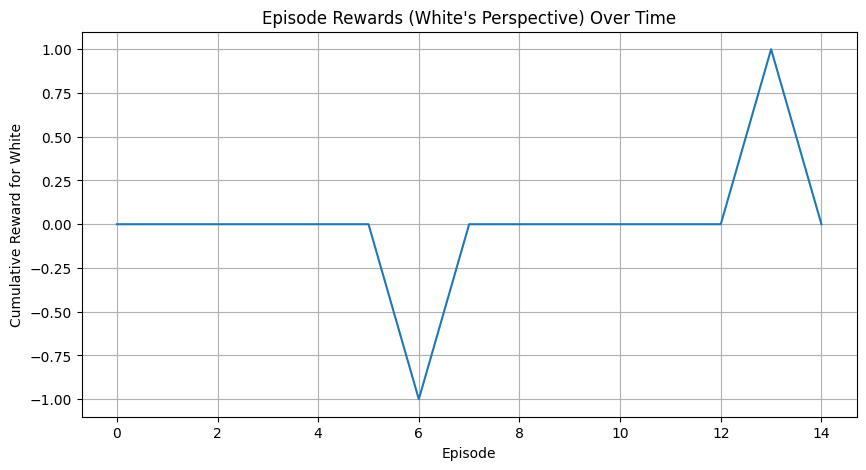

In [17]:
# (Ensure Cells 1-4 have run successfully)
# This cell requires:
# - `chess` module
# - `torch`, `torch.optim`
# - `random`, `collections.deque`
# - `gnn_model` (instance of ChessGNN from Cell 3, on DEVICE)
# - `SimpleGNNAgent` (class from Cell 4)
# - `board_to_graph_data` (function from Cell 2, outputting Data on DEVICE)
# - `Batch` from `torch_geometric.data`
# - `DEVICE` (from Cell 1)

from collections import deque # For the replay buffer

# --- Hyperparameters for Training ---
LEARNING_RATE = 1e-4      # Learning rate for the GNN optimizer
GAMMA = 0.99              # Discount factor for future rewards
REPLAY_BUFFER_SIZE = 10000 # Maximum size of the replay buffer (keep small for Colab initially)
BATCH_SIZE_RL = 64        # Number of experiences to sample from buffer for learning
# TARGET_UPDATE_FREQ = 10 # Episodes between updating target network (if we had one)

NUM_EPISODES = 15       # Total number of self-play games to simulate (small for demo)
MAX_STEPS_PER_EPISODE = 200 # Max moves per game to prevent infinite loops
EPSILON_START = 1.0       # Initial exploration rate for agents
EPSILON_END = 0.05        # Minimum exploration rate
EPSILON_DECAY_RATE = 0.995 # Multiplicative decay factor for epsilon per episode

# --- Setup ---

# Ensure gnn_model is available (should be from Cell 3)
if 'gnn_model' not in globals():
    raise NameError("gnn_model not defined. Please run Cell 3 first to create it.")
if 'SimpleGNNAgent' not in globals():
    raise NameError("SimpleGNNAgent class not defined. Please run Cell 4 first.")

# The GNN will be trained, so set it to train mode initially for the loop
# The agent's select_action method will set it to eval() mode internally for inference.
gnn_model.train() # Set GNN to training mode for learning steps

# Optimizer for the GNN (which acts as our value network)
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=LEARNING_RATE)

# Replay buffer to store experiences: (state_fen, action_uci, reward, next_state_fen, done)
replay_buffer = deque(maxlen=REPLAY_BUFFER_SIZE)

# Initialize two agents for self-play. They will share the same GNN instance.
# Epsilon values will be managed per agent if they had separate GNNs,
# but since they share a GNN, epsilon decay could be global or per "turn type" in an episode.
# For simplicity here, let's make two agent instances for conceptual clarity,
# but they will use the same epsilon logic.
# The current SimpleGNNAgent manages its own epsilon.
# Let's have the loop control the epsilon and pass it.
# agent_white = SimpleGNNAgent(gnn_model_to_use=gnn_model, epsilon_start=EPSILON_START, epsilon_end=EPSILON_END, epsilon_decay=EPSILON_DECAY_RATE)
# agent_black = SimpleGNNAgent(gnn_model_to_use=gnn_model, epsilon_start=EPSILON_START, epsilon_end=EPSILON_END, epsilon_decay=EPSILON_DECAY_RATE)
# Simpler: one agent, just change board.turn
# Actually, the SimpleGNNAgent class manages its own epsilon. For now, let's use one shared agent instance for simplicity in the loop
# to demonstrate training. If you had two distinct agents learning differently, you'd need two.
# Since both players use the *same* GNN and logic, one agent object suffices.
current_epsilon = EPSILON_START
agent = SimpleGNNAgent(gnn_model_to_use=gnn_model, epsilon_start=current_epsilon, epsilon_end=EPSILON_END, epsilon_decay=EPSILON_DECAY_RATE)


def get_reward_for_game_end(board, player_color_that_just_moved):
    """
    Calculates reward based on game outcome for the player who just made the move.
    Assumes board.turn is now the *other* player.
    """
    if board.is_checkmate():
        # If board.turn is WHITE, it means BLACK just delivered checkmate.
        # So, if player_color_that_just_moved was BLACK, they get +1. If WHITE, -1.
        return 1.0 if board.turn != player_color_that_just_moved else -1.0
    elif board.is_stalemate() or \
         board.is_insufficient_material() or \
         board.is_seventyfive_moves() or \
         board.is_fivefold_repetition():
        return 0.0 # Draw
    return 0.0 # No terminal reward if game is not over

def learn_from_buffer():
    """
    Samples experiences from the replay buffer and trains the GNN (value network).
    Returns the loss value.
    """
    if len(replay_buffer) < BATCH_SIZE_RL:
        return None # Not enough experiences to learn yet

    minibatch = random.sample(replay_buffer, BATCH_SIZE_RL)

    # Unpack experiences
    # (state_fen, action_uci, reward, next_state_fen, done)
    states_fen = [exp[0] for exp in minibatch]
    # actions_uci = [exp[1] for exp in minibatch] # Action not directly used for V(s) learning
    rewards = torch.tensor([exp[2] for exp in minibatch], dtype=torch.float).to(DEVICE)
    next_states_fen = [exp[3] for exp in minibatch]
    dones = torch.tensor([exp[4] for exp in minibatch], dtype=torch.float).to(DEVICE) # 1.0 if done, 0.0 if not

    # Convert FEN strings to batched graph data for current states
    current_graph_data_list = []
    for fen in states_fen:
        b = chess.Board(fen)
        current_graph_data_list.append(board_to_graph_data(b)) # Should put data on DEVICE

    batched_current_states = Batch.from_data_list(current_graph_data_list).to(DEVICE)

    # Convert FEN strings to batched graph data for next states
    next_graph_data_list = []
    for fen in next_states_fen:
        b = chess.Board(fen) # Reconstruct board from FEN
        # If the state was terminal, the "next_state" graph data is not strictly needed for V(s'),
        # but we create dummy graphs for consistent batching.
        # V(s_terminal) is 0 by definition.
        next_graph_data_list.append(board_to_graph_data(b))

    batched_next_states = Batch.from_data_list(next_graph_data_list).to(DEVICE)

    # --- Calculate TD Target ---
    # 1. Get V(s') for all next states from the GNN
    gnn_model.eval() # Set GNN to eval mode for predicting V(s')
    with torch.no_grad():
        next_state_values = gnn_model(batched_next_states).squeeze() # Shape: [BATCH_SIZE_RL]
    gnn_model.train() # Set GNN back to train mode

    # 2. TD Target = reward + gamma * V(s') * (1 - done)
    #    If a state is 'done', its V(s') contributes 0 to the target.
    td_targets = rewards + (GAMMA * next_state_values * (1 - dones))

    # --- Calculate Loss ---
    # 1. Get V(s) for current states from the GNN
    current_state_values = gnn_model(batched_current_states).squeeze() # Shape: [BATCH_SIZE_RL]

    # 2. Loss is Mean Squared Error between V(s) and TD Target
    loss = F.mse_loss(current_state_values, td_targets)

    # --- Optimization Step ---
    optimizer.zero_grad()
    loss.backward()
    # Optional: Gradient clipping if gradients explode
    # torch.nn.utils.clip_grad_norm_(gnn_model.parameters(), max_norm=1.0)
    optimizer.step()

    return loss.item()

# --- Main Training Loop ---
print(f"\n--- Starting Self-Play Training for {NUM_EPISODES} Episodes ---")
episode_rewards_history = []
total_steps = 0

for episode in range(NUM_EPISODES):
    board = chess.Board()
    current_player_agent = SimpleGNNAgent(gnn_model, epsilon_start=current_epsilon, epsilon_end=EPSILON_END, epsilon_decay=1.0) # Epsilon controlled by outer loop
    episode_reward_white = 0 # Track rewards from White's perspective for logging

    for step in range(MAX_STEPS_PER_EPISODE):
        total_steps += 1
        current_fen = board.fen() # State s
        player_color_moving = board.turn # chess.WHITE or chess.BLACK

        legal_moves = list(board.legal_moves)
        if not legal_moves or board.is_game_over():
            break # Game ended

        # Agent selects a move
        # The current SimpleGNNAgent implementation manages its own epsilon from its init.
        # If we want global epsilon:
        # current_player_agent.epsilon = current_epsilon
        # Better yet, SimpleGNNAgent can take epsilon as an argument to select_action if preferred.
        # For now, let's assume we re-create or update the agent's epsilon for the episode.
        # The agent in Cell 4 actually decays its own epsilon. Let's use THAT epsilon.

        # For clarity: The `agent` object uses its own internally managed epsilon.
        # Its epsilon will decay over many select_action calls across episodes.
        move = agent.select_action(board, legal_moves) # Action a

        if move is None: # Should not happen if legal_moves is not empty
            print(f"Episode {episode+1}, Step {step+1}: Agent returned None move. Board:\n{board.fen()}")
            break

        # Apply move and get next state and immediate reward
        board.push(move)
        next_fen = board.fen() # State s'
        done = board.is_game_over()

        # Reward: for simplicity, 0 for non-terminal, game outcome reward at the end
        # The experience stored will have the immediate reward + gamma * V(s') as target for V(s).
        # So, the direct 'reward' in the tuple is usually the immediate one.
        # For game end, the final reward is critical.
        # Let's assign terminal reward based on the player *who made the move that ended the game*

        reward_for_move = 0.0 # Default immediate reward
        if done:
            reward_for_move = get_reward_for_game_end(board, player_color_moving)

        # Store experience in replay buffer
        # (state, action_uci, reward, next_state, done)
        replay_buffer.append((current_fen, move.uci(), reward_for_move, next_fen, done))

        # Accumulate reward for White for logging this episode
        if player_color_moving == chess.WHITE and done:
            episode_reward_white += reward_for_move
        elif player_color_moving == chess.BLACK and done:
            episode_reward_white -= reward_for_move # If Black won, it's a negative for White

        # Learn from buffer
        loss_val = learn_from_buffer() # This trains gnn_model

        if done:
            break # End current episode

    # End of Episode
    # Decay the shared/global epsilon for the agent for the next episode
    current_epsilon = max(EPSILON_END, current_epsilon * EPSILON_DECAY_RATE)
    agent.epsilon = current_epsilon # Update the agent's epsilon for the next game if it's managed this way
    # The agent.decay_epsilon() would also work if we called it here for the 'agent' instance.

    episode_rewards_history.append(episode_reward_white)

    if (episode + 1) % 1 == 0: # Log every episode
        print(f"Episode {episode+1}/{NUM_EPISODES} finished after {step+1} steps. Result: {board.result() if done else 'timeout'}. "
              f"Buffer: {len(replay_buffer)}. Epsilon: {agent.epsilon:.3f}. Last Loss: {loss_val if loss_val is not None else 'N/A'}. "
              f"Ep Reward (W): {episode_reward_white:.1f}")

    # Optional: Save GNN model checkpoint periodically
    # if (episode + 1) % 20 == 0: # Every 20 episodes
    #     checkpoint_path = f'/content/drive/MyDrive/chess_bot/gnn_checkpoint_ep{episode+1}.pth'
    #     torch.save(gnn_model.state_dict(), checkpoint_path)
    #     print(f"Saved GNN checkpoint to {checkpoint_path}")

    # Optional: Garbage collection if memory is an issue in Colab
    # if (episode + 1) % 50 == 0:
    #    gc.collect()
    #    torch.cuda.empty_cache()

print("\n--- Training Finished ---")

# Plotting episode rewards (optional, requires matplotlib)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(episode_rewards_history)
plt.title("Episode Rewards (White's Perspective) Over Time")
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward for White")
plt.grid(True)
plt.show()

In [18]:
# (Ensure Cells 1-5 have been run. `gnn_model` should be trained from Cell 5)
# This cell requires:
# - `chess` module
# - `torch`
# - `gnn_model` (instance of ChessGNN from Cell 3, trained in Cell 5, on DEVICE)
# - `SimpleGNNAgent` (class from Cell 4)
# - `board_to_graph_data` (function from Cell 2, outputting Data on DEVICE)
# - `DEVICE` (from Cell 1)
# - (Optional) Google Drive mounted if saving there

# --- 1. Save the Trained GNN Model ---
print("--- Saving Trained GNN Model ---")
# Ensure gnn_model is available
if 'gnn_model' not in globals():
    print("ERROR: `gnn_model` not found. Was Cell 5 (training) run and completed successfully?")
else:
    try:
        # Define path for saving. Using Colab's local storage first.
        # For persistence across sessions, save to Google Drive if mounted.
        gnn_model_save_path_local = "trained_chess_gnn.pth"
        # gnn_model_save_path_drive = "/content/drive/MyDrive/chess_bot/trained_chess_gnn_final.pth" # Example Drive path

        torch.save(gnn_model.state_dict(), gnn_model_save_path_local)
        print(f"Trained GNN model state_dict saved to: {gnn_model_save_path_local}")

        # If you want to save to Google Drive:
        # from google.colab import drive
        # import os
        # try:
        #     drive.mount('/content/drive', force_remount=True) # force_remount if it was already mounted
        #     if not os.path.exists("/content/drive/MyDrive/chess_bot"):
        #         os.makedirs("/content/drive/MyDrive/chess_bot")
        #     torch.save(gnn_model.state_dict(), gnn_model_save_path_drive)
        #     print(f"Trained GNN model state_dict also saved to: {gnn_model_save_path_drive}")
        # except Exception as e:
        #     print(f"Could not save to Google Drive: {e}")

    except Exception as e:
        print(f"Error saving GNN model: {e}")

# --- 2. Load the Trained GNN Model (Demonstration) ---
# This shows how you would load it in a new session or for later use.
print("\n--- Demonstrating Loading the Trained GNN Model ---")
try:
    # Re-initialize a GNN model structure (must match the saved one's architecture)
    # Make sure NUM_NODE_FEATURES is defined (from Cell 1)
    # The parameters (hidden_channels, num_layers) must match the `gnn_model` used in training.
    # Let's assume `gnn_model` from training has hidden_channels=32, num_layers=2 based on Cell 3 and 5 setup.
    loaded_gnn_model = ChessGNN(in_channels=NUM_NODE_FEATURES, hidden_channels=32, num_layers=2).to(DEVICE)

    # Load the state dictionary
    loaded_gnn_model.load_state_dict(torch.load(gnn_model_save_path_local, map_location=DEVICE))
    loaded_gnn_model.eval() # Set to evaluation mode
    print("Trained GNN model loaded successfully and set to evaluation mode.")

    # You can now use `loaded_gnn_model` for inference.
except Exception as e:
    print(f"Error loading GNN model: {e}. Make sure '{gnn_model_save_path_local}' exists and model architecture matches.")
    loaded_gnn_model = None # Ensure it's None if loading failed


# --- 3. Evaluate the Trained Agent ---
print("\n--- Evaluating the Trained Agent (Using Loaded Model) ---")

if loaded_gnn_model is None: # or gnn_model if you want to use the one directly from training
    print("Evaluation skipped as loaded_gnn_model is not available.")
else:
    # Create an agent instance with the trained (loaded) GNN
    # Set epsilon to a very low value for evaluation (mostly greedy moves)
    eval_agent = SimpleGNNAgent(gnn_model_to_use=loaded_gnn_model, epsilon_start=0.01, epsilon_end=0.01, epsilon_decay=1.0)
    # eval_agent = SimpleGNNAgent(gnn_model_to_use=gnn_model, epsilon_start=0.01, epsilon_end=0.01, epsilon_decay=1.0) # to use model directly from training

    NUM_EVAL_GAMES = 5 # Play a few games to see its behavior
    MAX_STEPS_EVAL = 100  # Max moves per evaluation game

    wins_as_white = 0
    wins_as_black = 0
    draws = 0

    for i_eval_game in range(NUM_EVAL_GAMES):
        board = chess.Board()
        print(f"\nStarting Evaluation Game {i_eval_game + 1}/{NUM_EVAL_GAMES}")

        # For simplicity, the agent plays against itself.
        # To play against a random agent:
        # Define a RandomAgent class or function `select_random_move(board, legal_moves)`
        # And alternate turns between `eval_agent` and the random agent.

        current_turn_player = "eval_agent" # Let's make eval_agent play both White and Black here
                                         # Or alternate eval_agent (White) vs random_agent (Black)

        for step in range(MAX_STEPS_EVAL):
            legal_moves = list(board.legal_moves)
            if not legal_moves or board.is_game_over():
                break

            if board.turn == chess.WHITE: # White's turn
                # print(f"Game {i_eval_game+1} Step {step+1} (W): Eval Agent's turn")
                move = eval_agent.select_action(board, legal_moves)
            else: # Black's turn
                # For self-play evaluation, eval_agent plays Black too.
                # For playing against a fixed opponent (e.g., random):
                # move = random.choice(legal_moves) if opponent == "random" else eval_agent.select_action(board, legal_moves)
                # print(f"Game {i_eval_game+1} Step {step+1} (B): Eval Agent's turn")
                move = eval_agent.select_action(board, legal_moves)


            if move:
                # print(f"Move: {move.uci()}")
                board.push(move)
            else:
                print("Agent returned no move, ending game.")
                break

        # Game finished for this evaluation episode
        result = board.result()
        print(f"Evaluation Game {i_eval_game + 1} finished. Result: {result}. Moves: {board.fullmove_number}")
        # print(board) # Print final board state

        if result == "1-0": # White wins
            wins_as_white += 1
        elif result == "0-1": # Black wins
            wins_as_black +=1
        elif result == "1/2-1/2": # Draw
            draws += 1
        else: # Game incomplete (e.g. due to MAX_STEPS_EVAL) or other
            print(f"Game ended with status: {result} (could be due to step limit)")

    print("\n--- Evaluation Summary ---")
    print(f"Total Evaluation Games: {NUM_EVAL_GAMES}")
    # The following stats are from eval_agent playing itself
    print(f"White (Eval Agent) Wins: {wins_as_white}")
    print(f"Black (Eval Agent) Wins: {wins_as_black}")
    print(f"Draws: {draws}")

# --- 4. Optional: Interactive Play (Very Basic) ---
# This part is more complex to make robust, but here's a conceptual start
# print("\n--- Basic Interactive Play (Type 'quit' to exit) ---")
# if loaded_gnn_model: # or gnn_model
#     interactive_agent = SimpleGNNAgent(gnn_model_to_use=loaded_gnn_model, epsilon_start=0, epsilon_end=0, epsilon_decay=1) # Purely greedy
#     game_board = chess.Board()
#     while not game_board.is_game_over():
#         print("\nCurrent board:")
#         print(game_board)
#         if game_board.turn == chess.WHITE: # Assume Human plays White for this example
#             print("Your turn (as White).")
#             human_move_uci = input("Enter your move in UCI format (e.g., e2e4): ").strip().lower()
#             if human_move_uci == 'quit':
#                 break
#             try:
#                 move = game_board.parse_uci(human_move_uci)
#                 if move in game_board.legal_moves:
#                     game_board.push(move)
#                 else:
#                     print("Illegal move. Try again.")
#                     continue
#             except ValueError:
#                 print("Invalid UCI format. Try again.")
#                 continue
#         else: # Bot plays Black
#             print("Bot's turn (as Black)...")
#             legal_moves_bot = list(game_board.legal_moves)
#             if not legal_moves_bot: break
#             bot_move = interactive_agent.select_action(game_board, legal_moves_bot)
#             if bot_move:
#                 print(f"Bot plays: {bot_move.uci()}")
#                 game_board.push(bot_move)
#             else:
#                 print("Bot has no move.")
#                 break
#         print("-" * 20)
#
#     print("\nGame Over!")
#     print(f"Result: {game_board.result()}")
#     print("Final board:")
#     print(game_board)
# else:
#     print("Interactive play skipped as model not available.")

--- Saving Trained GNN Model ---
Trained GNN model state_dict saved to: trained_chess_gnn.pth

--- Demonstrating Loading the Trained GNN Model ---
Trained GNN model loaded successfully and set to evaluation mode.

--- Evaluating the Trained Agent (Using Loaded Model) ---

Starting Evaluation Game 1/5
Evaluation Game 1 finished. Result: 1/2-1/2. Moves: 28

Starting Evaluation Game 2/5
Evaluation Game 2 finished. Result: 1/2-1/2. Moves: 28

Starting Evaluation Game 3/5
Evaluation Game 3 finished. Result: 1/2-1/2. Moves: 44

Starting Evaluation Game 4/5
Evaluation Game 4 finished. Result: 1/2-1/2. Moves: 47

Starting Evaluation Game 5/5
Evaluation Game 5 finished. Result: 1/2-1/2. Moves: 28

--- Evaluation Summary ---
Total Evaluation Games: 5
White (Eval Agent) Wins: 0
Black (Eval Agent) Wins: 0
Draws: 5


--- INTERACTIVE CHESS: Turn 2 ---


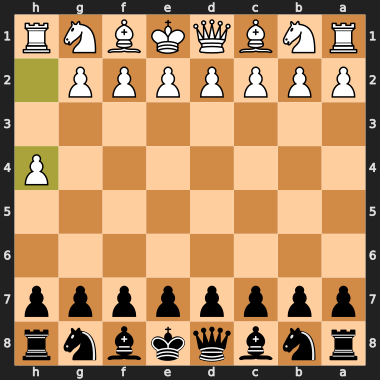


FEN: rnbqkbnr/pppppppp/8/8/7P/8/PPPPPPP1/RNBQKBNR b KQkq - 0 1
Turn: Black to move.
Last move by opponent: h2h4

YOUR TURN (Black).
Legal moves available (examples - Promotion moves will include 'q', 'r', 'b', or 'n'):
  1. g8h6
  2. g8f6
  3. b8c6
  4. b8a6
  5. h7h6
  6. g7g6
  7. f7f6
  8. e7e6
  9. d7d6
  10. c7c6
  ... and 10 more.


KeyboardInterrupt: Interrupted by user

In [27]:
# (Ensure Cells 1, 2, 3, 4, and 5 (training) have been run)
# Required: chess, chess.svg, IPython.display, torch, random
#           gnn_model (or saved file), SimpleGNNAgent, board_to_graph_data,
#           ChessGNN class, NUM_NODE_FEATURES, DEVICE

import time
import random
import chess
import chess.svg
from IPython.display import display, SVG, clear_output

print("--- Setting up for Interactive Play with Visual Board ---")

# --- Configuration for Model Loading ---
GNN_HIDDEN_CHANNELS = 32
GNN_NUM_LAYERS = 2
SAVED_MODEL_FILENAME = "trained_chess_gnn.pth"

interactive_gnn = None

if 'gnn_model' in globals() and isinstance(gnn_model, ChessGNN):
    print("INFO: Using GNN model directly from the current training session.")
    interactive_gnn = gnn_model
    interactive_gnn.eval()
else:
    print("INFO: `gnn_model` from current session not found or unsuitable. Attempting to load from file...")
    try:
        print(f"INFO: Attempting to load model from '{SAVED_MODEL_FILENAME}' with arch: hidden_channels={GNN_HIDDEN_CHANNELS}, num_layers={GNN_NUM_LAYERS}.")
        loaded_model_instance = ChessGNN(in_channels=NUM_NODE_FEATURES,
                                        hidden_channels=GNN_HIDDEN_CHANNELS,
                                        num_layers=GNN_NUM_LAYERS).to(DEVICE)
        loaded_model_instance.load_state_dict(torch.load(SAVED_MODEL_FILENAME, map_location=DEVICE))
        loaded_model_instance.eval()
        interactive_gnn = loaded_model_instance
        print(f"INFO: Successfully loaded GNN model from '{SAVED_MODEL_FILENAME}'.")
    except FileNotFoundError:
        print(f"ERROR: Saved model file '{SAVED_MODEL_FILENAME}' not found. Cannot start interactive play.")
    except Exception as e_load:
        print(f"ERROR: Could not load GNN model from file: {e_load}")

if interactive_gnn:
    bot_player = SimpleGNNAgent(gnn_model_to_use=interactive_gnn,
                               epsilon_start=0.0, epsilon_end=0.0, epsilon_decay=1.0)
    print("INFO: Bot player initialized with trained GNN (greedy mode).")

    game_board = chess.Board()
    human_plays_as = None
    game_active = True

    while human_plays_as not in [chess.WHITE, chess.BLACK] and game_active:
        try:
            choice = input("Do you want to play as White (w) or Black (b)? Type 'quit' to exit setup: ").strip().lower()
            if choice == 'w': human_plays_as = chess.WHITE
            elif choice == 'b': human_plays_as = chess.BLACK
            elif choice == 'quit': game_active = False; print("\nINFO: Exiting interactive play setup.")
            else: print("Invalid choice. Please enter 'w', 'b', or 'quit'.")
        except KeyboardInterrupt: game_active = False; print("\nINFO: Keyboard interrupt during setup. Exiting.")
        except Exception as e_setup: game_active = False; print(f"ERROR: An error occurred during setup: {e_setup}")

    if game_active:
        print(f"\nINFO: You are playing as {'White' if human_plays_as == chess.WHITE else 'Black'}.")
        print("       Type 'quit' at any time to end the game.")
        print("       Moves MUST be in UCI format (e.g., 'e2e4', 'g1f3').")
        # <<< NEW INSTRUCTION FOR PROMOTION >>>
        print("       FOR PAWN PROMOTION: append the desired piece to the UCI string,")
        print("         e.g., 'e7e8q' (Queen), 'e7e8r' (Rook), 'e7e8b' (Bishop), 'e7e8n' (Knight).")
        # <<< END NEW INSTRUCTION >>>

        turn_count = 0
        while not game_board.is_game_over() and game_active:
            turn_count += 1
            clear_output(wait=True)

            print(f"--- INTERACTIVE CHESS: Turn {turn_count} ---")
            last_move_obj = game_board.peek() if game_board.move_stack else None
            board_svg_data = chess.svg.board(
                board=game_board,
                lastmove=last_move_obj,
                orientation=human_plays_as,
                size=380
            )
            display(SVG(board_svg_data))

            print(f"\nFEN: {game_board.fen()}")
            current_player_color_str = 'White' if game_board.turn == chess.WHITE else 'Black'
            print(f"Turn: {current_player_color_str} to move.")
            if last_move_obj:
                # Print if the last move was a promotion
                if last_move_obj.promotion:
                    promoted_piece_char = chess.piece_symbol(last_move_obj.promotion).upper()
                    print(f"Last move by opponent: {last_move_obj.uci()} (Promoted to {promoted_piece_char}!)")
                else:
                    print(f"Last move by opponent: {last_move_obj.uci()}")
            print("="*45)

            is_human_turn = (game_board.turn == human_plays_as)

            if is_human_turn:
                print(f"\nYOUR TURN ({current_player_color_str}).")
                current_legal_moves = list(game_board.legal_moves)

                print("Legal moves available (examples - Promotion moves will include 'q', 'r', 'b', or 'n'):")
                if not current_legal_moves: print("  No legal moves (this means game is likely over).")
                else:
                    for lm_idx, lm in enumerate(current_legal_moves[:10]): print(f"  {lm_idx + 1}. {lm.uci()}") # Show more examples
                    if len(current_legal_moves) > 10: print(f"  ... and {len(current_legal_moves) - 10} more.")

                valid_move_made = False
                while not valid_move_made and game_active:
                    time.sleep(0.1)
                    user_input_raw = input(f"Enter your move ({current_player_color_str}): ")
                    user_input = user_input_raw.strip().lower()

                    if user_input == 'quit':
                        game_active = False; print("INFO: Game ended by user.")
                        break

                    try:
                        move_attempt = game_board.parse_uci(user_input)
                        if move_attempt in current_legal_moves:
                            game_board.push(move_attempt)
                            # <<< PROMOTION CONFIRMATION FOR HUMAN >>>
                            if move_attempt.promotion:
                                promoted_piece_char = chess.piece_symbol(move_attempt.promotion).upper()
                                print(f"INFO: You promoted a pawn to {promoted_piece_char} on {chess.SQUARE_NAMES[move_attempt.to_square]}!")
                            # <<< END PROMOTION CONFIRMATION >>>
                            valid_move_made = True
                        else:
                            print(f"'{user_input_raw}' represents an ILLEGAL move. Please choose from legal moves or check format (e.g. 'e7e8q' for promotion).")
                    except ValueError:
                        print(f"Invalid move format: '{user_input_raw}'. Use UCI (e.g., 'e2e4' or 'e7e8q'). Try again.")

            else: # Bot's turn
                if not game_active: break

                print("\nBot's turn...")
                legal_moves_bot = list(game_board.legal_moves)
                bot_move_obj = None # To store the actual move object
                if not legal_moves_bot:
                    print("INFO: Bot has no legal moves. Game should be over.")
                    game_active = False
                else:
                    bot_move_obj = bot_player.select_action(game_board, legal_moves_bot)

                if bot_move_obj:
                    game_board.push(bot_move_obj)
                    # <<< PROMOTION CONFIRMATION FOR BOT >>>
                    # No need to print "Bot plays:" here if it's also a promotion,
                    # the info message about promotion covers it, and the board will update.
                    # The next turn's "Last move by opponent" will show the bot's move.
                    # (Handled by the "Last move by opponent" print at the start of the loop)
                    # <<< END PROMOTION CONFIRMATION FOR BOT >>>

                elif game_active:
                    print("CRITICAL INFO: Bot did not make a move.")
                    if legal_moves_bot :
                        print("INFO: Bot logic might have an issue. Bot picking random fallback move.")
                        random_fallback_move = random.choice(legal_moves_bot)
                        game_board.push(random_fallback_move)
                    else:
                        game_active = False

        clear_output(wait=True)
        if not game_active and turn_count > 0 and not game_board.is_game_over():
            print("--- INTERACTIVE CHESS ---")
            print("\nINFO: Interactive play terminated by user mid-game.")
            display(SVG(chess.svg.board(board=game_board, orientation=human_plays_as, size=380)))
            print(f"\nLast FEN: {game_board.fen()}")

        elif game_board.is_game_over():
            print("--- INTERACTIVE CHESS: GAME OVER! ---")
            final_board_svg = chess.svg.board(
                board=game_board,
                lastmove=game_board.peek() if game_board.move_stack else None,
                orientation=human_plays_as,
                size=380
            )
            display(SVG(final_board_svg))
            print(f"\nResult: {game_board.result()}")
            print(f"FEN: {game_board.fen()}")
        print("="*45)

elif not interactive_gnn:
    print("\nERROR: Interactive play cannot start as the GNN model is not available.")